# Cifar -10 data analysis

In this I have used spectral normalised in discriminator with power iteration 1.

In [1]:
import pandas as pd
from PIL import Image
import torch 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
splits = {'train': 'plain_text/train-00000-of-00001.parquet', 'test': 'plain_text/test-00000-of-00001.parquet'}
train_dataset = pd.read_parquet("hf://datasets/uoft-cs/cifar10/" + splits["train"])
test_dataset = pd.read_parquet("hf://datasets/uoft-cs/cifar10/" + splits["test"])

In [11]:
train_dataset.head()

,img,label
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,6
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,0
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,7


In [3]:
len(train_dataset), len(test_dataset)

(50000, 10000)

In [5]:
# for reading the binary files
import io

In [15]:
#for easy class ref
def get_class(x):
    match x:
        case 0:
            return "airplane"
        case 1:
            return "automobile"								
        case 2:
            return "bird"
        case 3:
            return "cat"
        case 4:
            return "deer"
        case 5:
            return "dog"
        case 6:
            return "frog"
        case 7:
            return "horse"
        case 8:
            return "ship"
        case 9:
            return "truck"

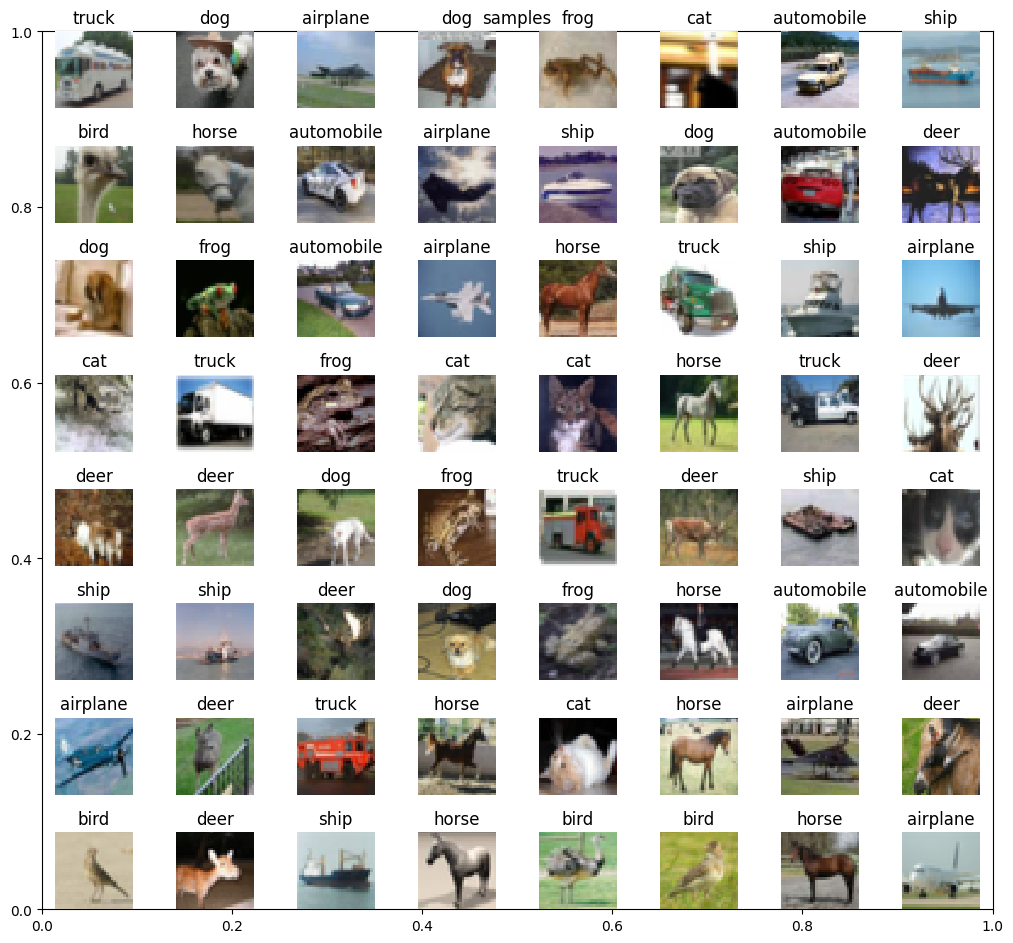

In [23]:
plt.figure(figsize=(10,10))
plt.title("samples")
ax.axis("off")
for i in range(64):
    ax = plt.subplot(8,8,i+1)
    x = np.random.randint(0,len(train_dataset))
    plt.imshow(torch.tensor(np.asarray(Image.open(io.BytesIO(train_dataset['img'][x]["bytes"])),dtype=np.float32)/255),interpolation='nearest')
    plt.title(get_class(train_dataset['label'][x]))
    plt.tight_layout()
    ax.axis("off")
plt.show()

as we can see that the subject has been placed at different angles and of differnt variaties (in case of bird they way differnt where in terms of horse they are kind of similar). Even at some places only head part is visible.

In [18]:
Image.open(io.BytesIO(train_dataset['img'][x]["bytes"])).size

(32, 32)

In [19]:
for i in range(10):
    print(len(train_dataset[train_dataset["label"]==i]))

5000
5000
5000
5000
5000
5000
5000
5000
5000
5000


Each image is of same size(32,32) and rgb. And is class is equally distributed

## looking into each classes and Examine the variety

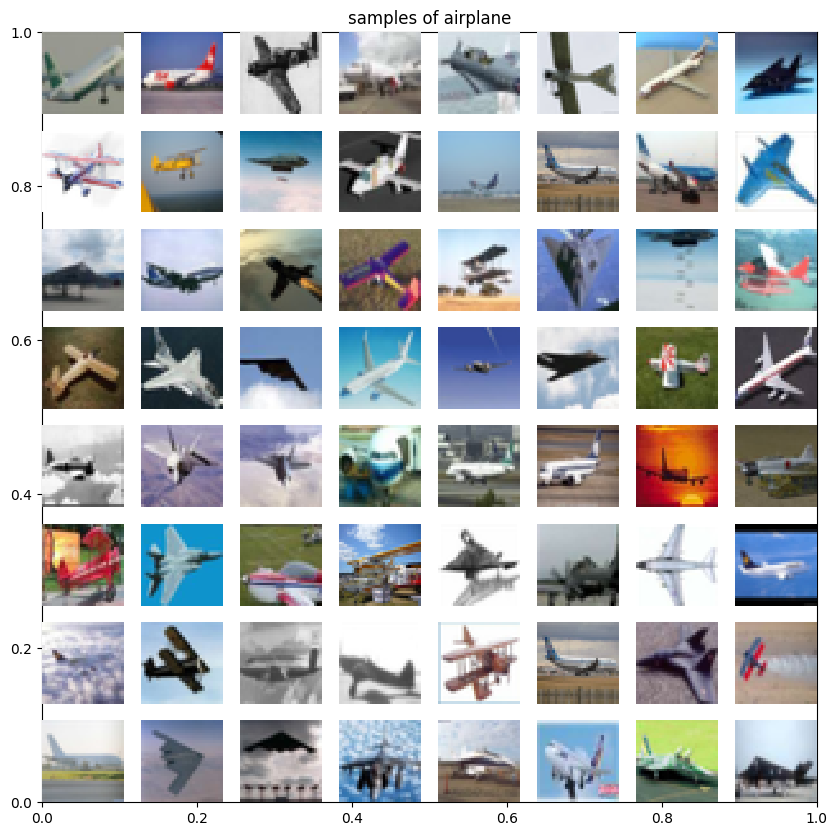

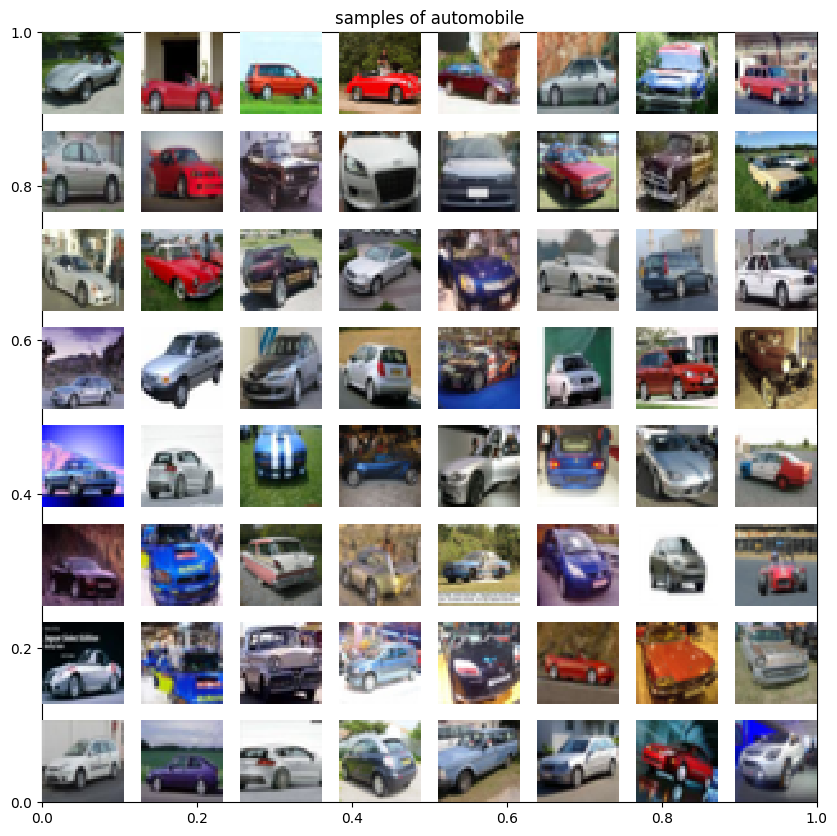

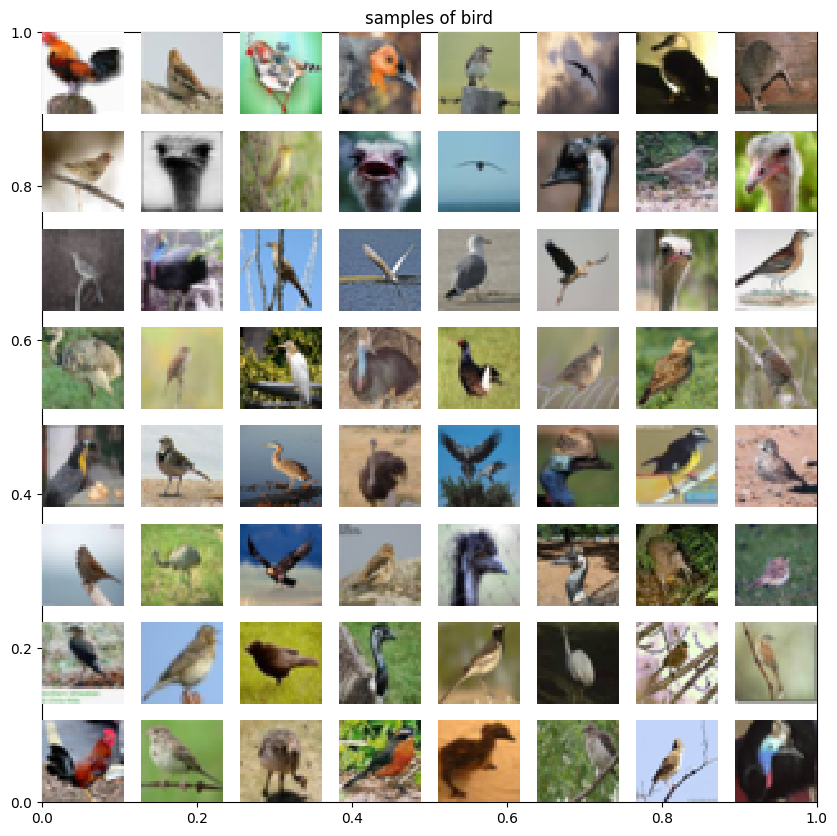

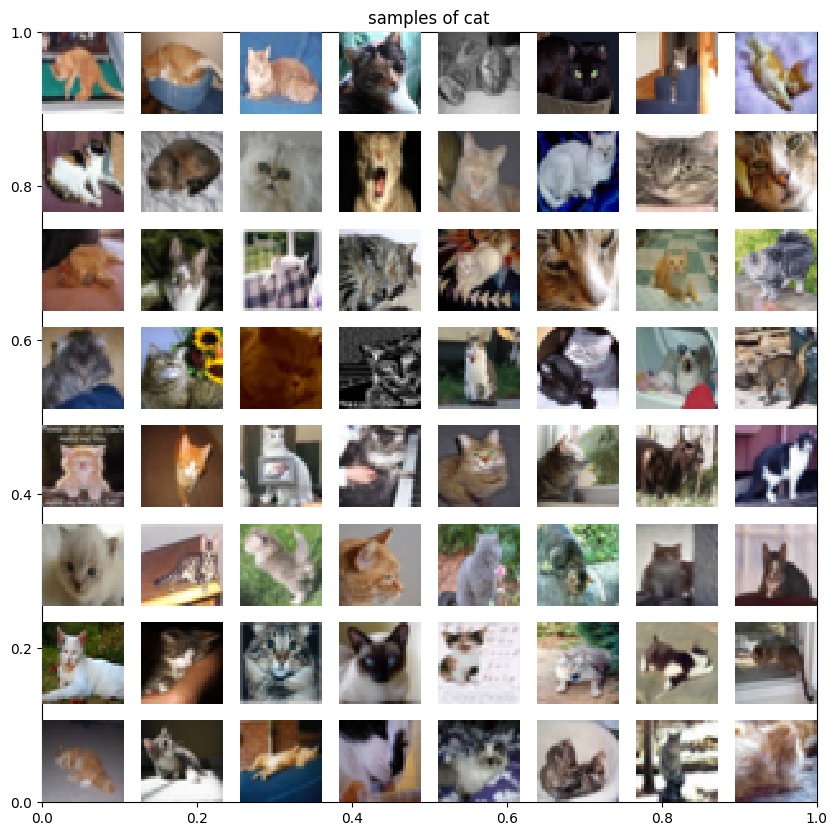

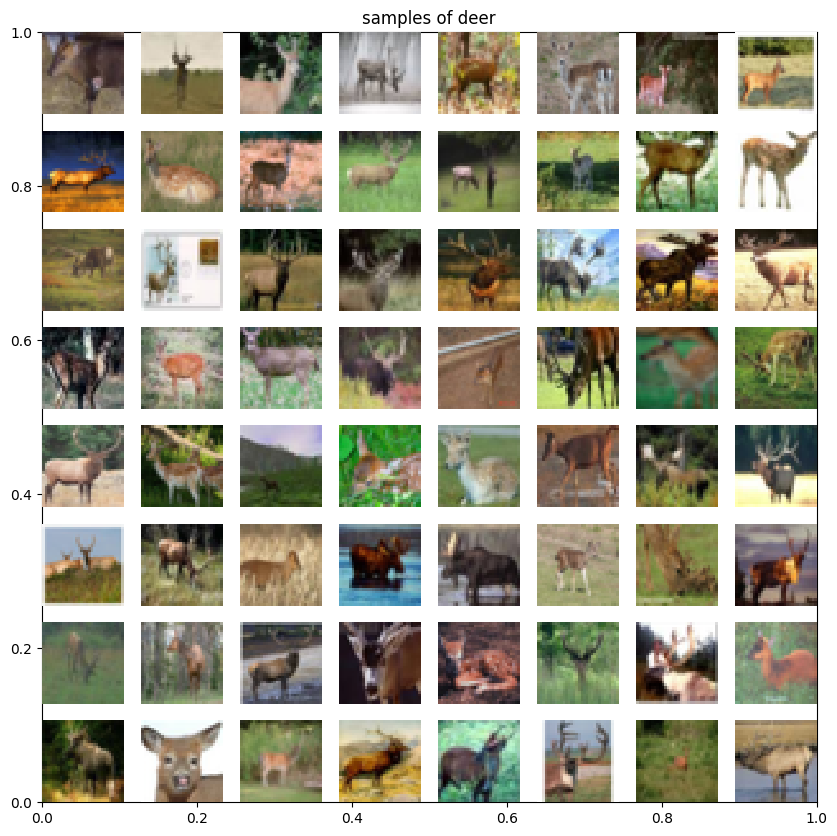

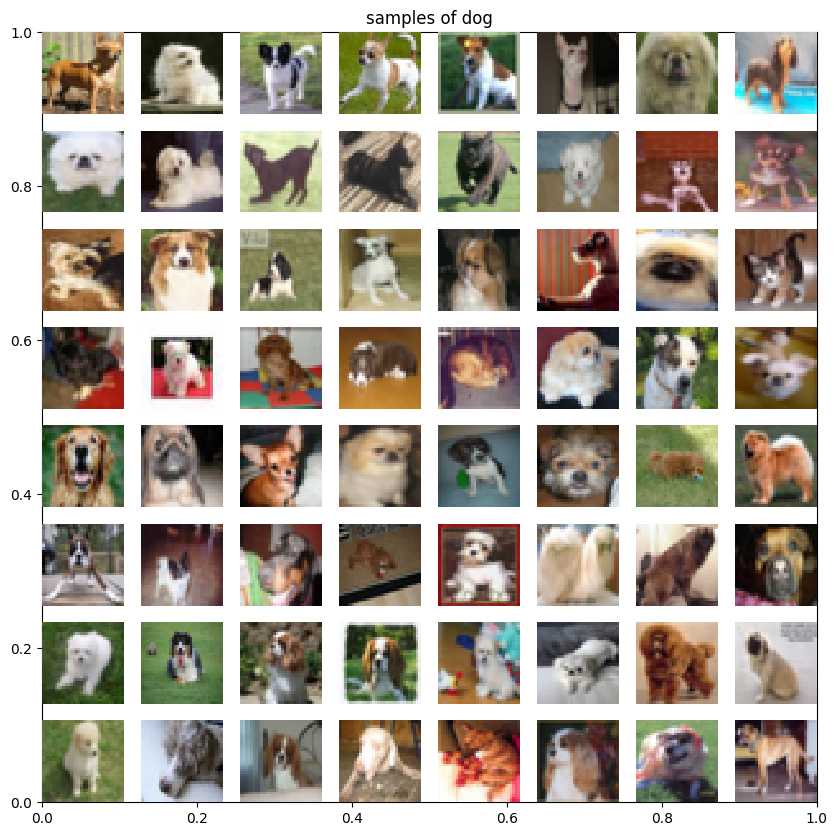

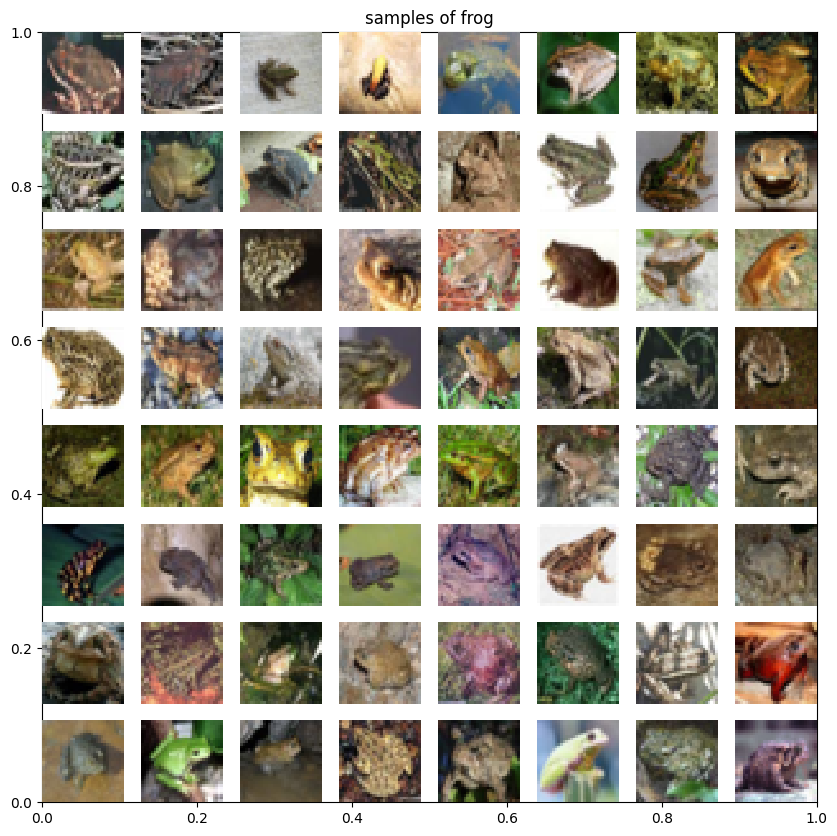

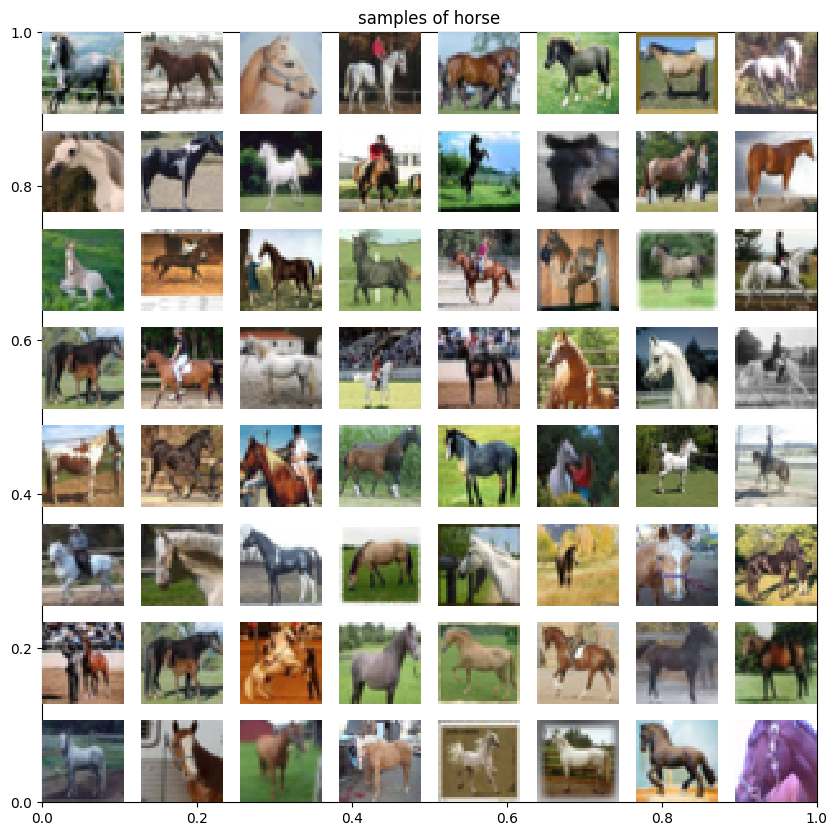

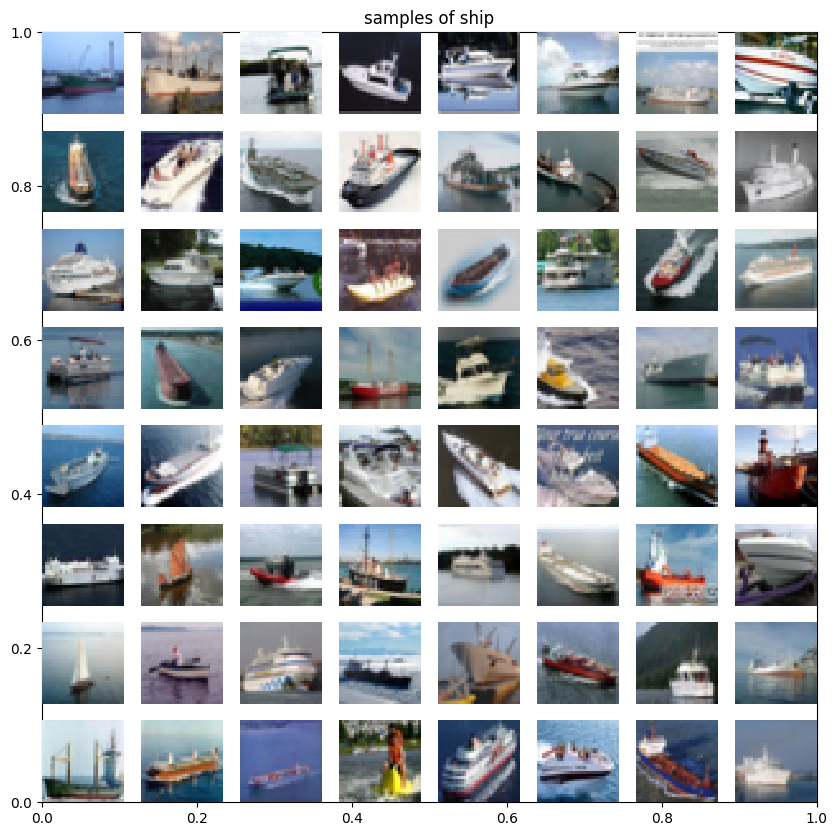

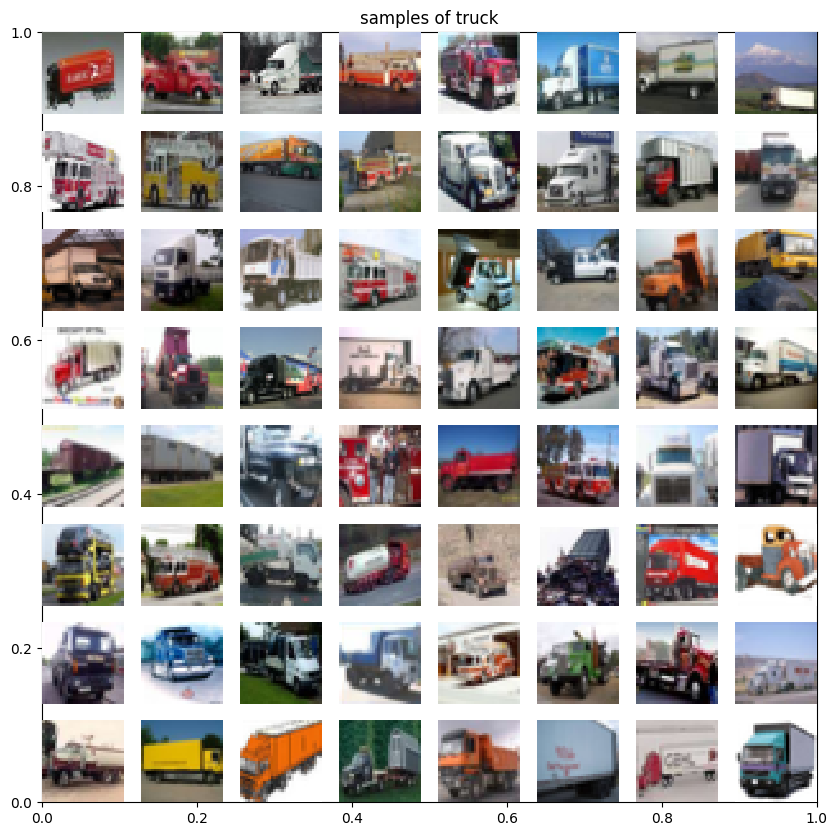

In [33]:
for j in range(10):
    plt.figure(figsize=(10,10))
    plt.title(f"samples of {get_class(j)}")
    ax.axis("off")
    
    samples = train_dataset[train_dataset["label"] == j].reset_index()
    
    for i in range(64):
        ax = plt.subplot(8,8,i+1)
        x = np.random.randint(0,len(samples))
        plt.imshow(torch.tensor(np.asarray(Image.open(io.BytesIO(samples['img'][x]["bytes"])),dtype=np.float32)/255),interpolation='nearest')
        ax.axis("off")
    plt.show()

as far as these, the previous observation holds

In [35]:
np.asarray(Image.open(io.BytesIO(train_dataset['img'][x]["bytes"])))

array([[[186, 204, 152],
        [190, 209, 149],
        [212, 232, 166],
        ...,
        [108, 121,  84],
        [128, 138, 107],
        [118, 125,  98]],

       [[157, 173, 121],
        [189, 205, 150],
        [204, 221, 162],
        ...,
        [133, 139, 110],
        [140, 147, 120],
        [134, 142, 116]],

       [[166, 181, 124],
        [192, 207, 151],
        [171, 186, 128],
        ...,
        [137, 136, 114],
        [130, 133, 110],
        [111, 118,  94]],

       ...,

       [[ 94, 141,  90],
        [ 84, 129,  80],
        [ 91, 133,  81],
        ...,
        [ 50,  90,  67],
        [ 51,  91,  63],
        [ 57,  95,  68]],

       [[ 84, 132,  80],
        [ 79, 123,  76],
        [ 75, 118,  73],
        ...,
        [ 48,  85,  64],
        [ 53,  90,  68],
        [ 52,  88,  67]],

       [[ 82, 130,  75],
        [ 76, 120,  70],
        [ 74, 117,  71],
        ...,
        [ 42,  75,  57],
        [ 42,  76,  58],
        [ 38,  71,  53]]

the values are in range 0 - 255 which xan be normalised.

so I move with normalising to (-1,1) as it the output of the tanh and has mean 0.

But in practice it resulted the model to converge to a subset of images. I used the normalised \[0,1\] and it worked as it pushed the model output to a different mean each time as the output are different.